Nanjing Monthly Weather Prediction Project

Project Introduction

This project takes the monthly meteorological data of Nanjing from 2020 to 2025 as the research object,

Construct classical time series models and Bayesian time series models separately,

Complete temperature series fitting, test set prediction, future short-term prediction, and result visualization comparison.

Model Introduction
1. AR univariate autoregressive model
2. ARIMA differential integrated moving average autoregressive model
3. VAR multivariate vector autoregression model
4. Bayesian AR Bayesian autoregressive model
5. Bayesian VAR multivariate vector autoregression model

Code structure
1. Library import and environment configuration
2. Data reading, cleaning, and time preprocessing
3. Dataset division: training set/testing set
4. Training and prediction of various classic models
5. Bayesian model construction and posterior sampling
6. Multiple sets of visual graphics and result display

Experimental Content
Univariate temperature time series prediction
Joint modeling of multivariate meteorological factors
Prediction Interval and Uncertainty Analysis
Visual comparison of fitting effects of different models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# AutoReg: Implementation class for the Autoregressive (AR) model
from statsmodels.tsa.ar_model import AutoReg
# VAR: Implementation class for the Vector Autoregressive (VAR) model (for multivariate time series)
from statsmodels.tsa.vector_ar.var_model import VAR
# ARIMA: Implementation class for the Autoregressive Integrated Moving Average (ARIMA) model
from statsmodels.tsa.arima.model import ARIMA
# adfuller: Augmented Dickey-Fuller (ADF) unit root test function, used to judge whether a time series is stationary (a core prerequisite for the ARIMA model)
from statsmodels.tsa.stattools import adfuller
# Used to calculate the Mean Squared Error (MSE), which is for subsequently computing the RMSE to evaluate the model
from sklearn.metrics import mean_squared_error
import math

In [2]:
# Load the cleaned monthly weather dataset
df = pd.read_csv("Nanjing_Weather_Monthly_2020_2025_Cleaned.csv")

# Extract core meteorological features (4 features, consistent with the previous LSTM model)
features = ['Average_Temperature(Celsius)', 'Humidity(percentage)', 
            'Wind_speed(m/s)', 'Air_pressure(hPa)']
df_core = df[features].copy()

# Set the time index for the dataset
# freq='ME' indicates monthly data (Month-end frequency, i.e., data corresponding to the end of each month)
df_core['Month'] = pd.date_range(start='2020-01', periods=len(df_core), freq='ME')
# Set the 'Month' column as the DataFrame index for easy time-based filtering and data visualization (plotting)
df_core.set_index('Month', inplace=True)

# Split the dataset into training set and test set (80:20 ratio)
train_size = int(0.8 * len(df_core))
train_data = df_core.iloc[:train_size]  # First 80% of the data as the training set
test_data = df_core.iloc[train_size:]   # Last 20% of the data as the test set

# Extract a univariate time series (a time series that contains only one single variable) 
# for AR and ARIMA models (select average temperature as the target variable)
temp_series = df_core['Average_Temperature(Celsius)']
temp_train = temp_series[:train_size]  # Training sequence of the average temperature
temp_test = temp_series[train_size:]   # Test sequence of the average temperature

print(f"Training set length: {len(train_data)}, Test set length: {len(test_data)}")

Training set length: 56, Test set length: 15


In [3]:
# AutoRegressive (AR) Model - Predicts future values using the historical lagged data of the series itself
# Core formula: y_t = c + φ1*y_{t-1} + φ2*y_{t-2} + ... + φp*y_{t-p} + ε_t
# Where p is the lag order, φ represents autoregressive coefficients, and ε_t is the random error term
import math  # Ensure math is imported (for sqrt) - added for completeness, consistent with previous code
from sklearn.metrics import mean_squared_error  # Ensure MSE is imported - added for completeness
from statsmodels.tsa.ar_model import AutoReg  # Ensure AutoReg is imported - added for completeness

def train_ar_model(train_series, test_series, lags=6):
    """
    Trains the AR model and performs predictions.
    :param train_series: Univariate time series for the training set
    :param test_series: Univariate time series for the test set
    :param lags: Lag order (p) - Uses the previous 'lags' periods of data to predict the current period, corresponding to the time_step of the LSTM model
    :return: Prediction result array, RMSE of the test set
    """
    # 1. Fit the AR model
    # AutoReg parameter explanation:
    # - endog: Endogenous variable (the time series to be predicted)
    # - lags: Lag order, set to 6 here (consistent with the time_step of the previous LSTM model)
    ar_model = AutoReg(train_series, lags=lags)
    # fit(): Trains the model and solves for the autoregressive coefficients (φ)
    ar_model_fit = ar_model.fit()
    
    # 2. Perform out-of-sample prediction (predict the test set data)
    # Out-of-sample Prediction - Predicts data unseen by the model (the test set), distinct from in-sample prediction
    # predict() parameter explanation:
    # - start: Start index of the prediction (end position of the training set)
    # - end: End index of the prediction (length of training set + length of test set - 1)
    # - dynamic: Dynamic/Static prediction; False means using actual historical data for prediction, 
    #   True means using model-predicted historical data for prediction
    ar_pred = ar_model_fit.predict(start=len(train_series), 
                                   end=len(train_series)+len(test_series)-1, 
                                   dynamic=False)
    
    # 3. Calculate RMSE to evaluate the model performance
    ar_rmse = math.sqrt(mean_squared_error(test_series, ar_pred))
    
    return ar_pred, ar_rmse

# Train the AR model (lag order = 6)
ar_predictions, ar_rmse = train_ar_model(temp_train, temp_test, lags=6)

# Print the AR model results
print(f"AR Model (Average Temperature) Test Set RMSE: {ar_rmse:.2f} °C")

AR Model (Average Temperature) Test Set RMSE: 1.80 °C


D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [4]:
# Vector AutoRegressive (VAR) Model - Processes multivariate time series
# Core: Simultaneously models the lagged correlations among multiple variables, where each variable is an endogenous variable affected by its own historical values and the historical values of other variables.
# Applicable scenarios: Scenarios where there are mutual influences between variables (e.g., temperature affects humidity, and humidity affects air pressure), 

def train_var_model(train_df, test_df):
    """
    Trains the VAR model and performs predictions.
    :param train_df: Multivariate DataFrame for the training set (each row represents a time point, each column represents a single variable)
    :param test_df: Multivariate DataFrame for the test set
    :return: Prediction result DataFrame, RMSE dictionary for each feature
    """
    
    # 1. Fit the VAR model (adapt the maximum lag order to avoid estimation errors)
    var_model = VAR(train_df)
    
    # Calculate the maximum allowed lag order (to ensure sufficient samples for model estimation)
    # Note: max_allowed_lags is derived from the training set size and number of variables (from previous code logic)
    train_samples = len(train_df)
    n_features = train_df.shape[1]
    max_allowed_lags = (train_samples - 1) // (n_features + 1)
    
    # Set the maximum lag order to the smaller of 6 and max_allowed_lags (to resolve "maxlags too large" error)
    maxlags = min(6, max_allowed_lags)  
    print(f"Maximum lag order attempted for this model: {maxlags}")
    
    # Optimal lag order - Selects the lag order that yields the best model fitting performance.
    # Common selection criteria include AIC (Akaike Information Criterion), BIC (Bayesian Information Criterion), and HQIC (Hannan-Quinn Information Criterion).
    # select_order() parameter explanation:
    # - maxlags: Maximum attempted lag order (reduced to 6 here to resolve the "maxlags is too large" error)
    # - Output: Optimal lag order corresponding to each criterion; the AIC criterion tends to select more complex models.
    var_opt_order = var_model.select_order(maxlags=maxlags)
    
    # Handle extreme cases: If no valid lag order is available (extremely small sample size), force the lag order to 1.
    if var_opt_order.selected_orders['aic'] is None:
        print("Sample size is too small, forcing lag order to 1.")
        opt_lag = 1
    else:
        opt_lag = var_opt_order.selected_orders['aic']
    print(f"Optimal lag order of the VAR model (AIC criterion): {opt_lag}")
    
    # 3. Fit the VAR model using the optimal lag order
    # fit(): Pass in the optimal lag order to train the VAR model and estimate the model coefficients.
    var_model_fit = var_model.fit(opt_lag)
    
    # 4. Perform out-of-sample prediction (predict the test set data)
    # k_ar: Lag order of the trained VAR model, obtained from the model attribute after fitting.
    # The forecast requires the last 'k_ar' periods of training data as the lagged input.
    lag_order = var_model_fit.k_ar
    var_pred = var_model_fit.forecast(train_df.values[-lag_order:], steps=len(test_df))
    
    # 5. Convert the prediction results to a DataFrame (for easy interpretation and subsequent processing)
    var_pred_df = pd.DataFrame(var_pred, columns=test_df.columns, index=test_df.index)
    
    # 6. Calculate the RMSE for each feature to evaluate the model's prediction performance
    var_rmse_dict = {}
    for feat in features:
        var_rmse = math.sqrt(mean_squared_error(test_df[feat], var_pred_df[feat]))
        var_rmse_dict[feat] = var_rmse
    
    return var_pred_df, var_rmse_dict

# Train the VAR model (input is the multivariate DataFrame containing 4 meteorological features)
var_predictions, var_rmse_dict = train_var_model(train_data[features], test_data[features])

# Print the VAR model results
for feat, rmse in var_rmse_dict.items():
    print(f"VAR Model ({feat}) Test Set RMSE: {rmse:.2f}")

Maximum lag order attempted for this model: 6
Optimal lag order of the VAR model (AIC criterion): 6
VAR Model (Average_Temperature(Celsius)) Test Set RMSE: 0.52
VAR Model (Humidity(percentage)) Test Set RMSE: 2.43
VAR Model (Wind_speed(m/s)) Test Set RMSE: 0.25
VAR Model (Air_pressure(hPa)) Test Set RMSE: 1.65


D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [5]:
# AutoRegressive Integrated Moving Average (ARIMA) Model - Core: AR(p) + I(d) + MA(q), used to process non-stationary time series.
# - p: Autoregressive order - Consistent with the lag order in the AR model.
# - d: Differencing order - Applies d times of differencing to a non-stationary series to convert it into a stationary series.
# - q: Moving average order - Uses the error terms of the previous q periods to predict the current period.
# Core prerequisite: The ARIMA model requires the input time series to be stationary; otherwise, differencing is necessary (d≥1).

# Auxiliary function: ADF Unit Root Test (to judge whether the time series is stationary)
def adf_test(series):
    """
    Augmented Dickey-Fuller (ADF) Unit Root Test - A commonly used method for testing time series stationarity.
    Null Hypothesis (H0): The series has a unit root and is non-stationary.
    Alternative Hypothesis (H1): The series has no unit root and is stationary.
    Judgment criterion: If the p-value < 0.05, reject the null hypothesis and the series is stationary; otherwise, it is non-stationary.
    :param series: The time series to be tested.
    :return: Boolean value indicating whether the series is stationary (True = stationary, False = non-stationary).
    """
    # adfuller() return values: Test statistic, p-value, lag order, sample size, critical values dictionary, etc.
    adf_result = adfuller(series)
    print(f"ADF Test Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")  # Core judgment indicator
    print(f"Critical Values (1%/5%/10% significance levels): {adf_result[4]}")
    
    if adf_result[1] < 0.05:
        print("Conclusion: The data is stationary (p<0.05, reject the null hypothesis), no differencing required (d=0).")
        return True
    else:
        # Note: In statistical testing, we "fail to reject H0" rather than "accept H0" (more rigorous academic expression)
        print("Conclusion: The data is non-stationary (p≥0.05, fail to reject the null hypothesis), differencing required (d≥1).")
        return False

# Perform stationarity test on the average temperature series (a necessary prerequisite for the ARIMA model)
print("Stationarity Test for the Average Temperature Series:")
is_stationary = adf_test(temp_series)

def train_arima_model(train_series, test_series, order=(6, 1, 2)):
    """
    Trains the ARIMA model and performs predictions.
    :param train_series: Univariate time series for the training set.
    :param test_series: Univariate time series for the test set.
    :param order: ARIMA order (p, d, q)
                  - p: Autoregressive order
                  - d: Differencing order (number of differencing times to make the series stationary)
                  - q: Moving average order
    :return: Prediction result array, RMSE of the test set.
    """
    # 1. Fit the ARIMA model
    # ARIMA parameter explanation:
    # - endog: Endogenous variable series (the time series to be predicted).
    # - order: (p,d,q) order, set based on empirical experience here (can be optimized via grid search).
    arima_model = ARIMA(train_series, order=order)
    # fit(): Trains the model and solves for the autoregressive coefficients and moving average coefficients.
    arima_model_fit = arima_model.fit()
    
    # 2. Perform out-of-sample prediction (predict the test set data)
    # predict() parameter explanation:
    # - typ='levels': Directly outputs predicted values in the original scale (automatic inverse differencing, no manual processing required).
    # - typ='linear': Outputs predicted values in the differenced scale (manual inverse differencing is required).
    arima_pred = arima_model_fit.predict(start=len(train_series), 
                                         end=len(train_series)+len(test_series)-1, 
                                         typ='levels')
    
    # 3. Calculate RMSE to evaluate the model's prediction performance
    arima_rmse = math.sqrt(mean_squared_error(test_series, arima_pred))
    
    return arima_pred, arima_rmse

# Train the ARIMA model (order setting logic)
# - p=6: Refer to the lag order of the previous AR model.
# - d=1 or 0: Determined by the ADF test result; d=1 for non-stationary series, d=0 for stationary series.
# - q=2: Moving average order, set based on empirical experience (can be optimized via grid search).
arima_order = (6, 1 if not is_stationary else 0, 2)
print(f"ARIMA Model Order Setting: {arima_order} (p={arima_order[0]}, d={arima_order[1]}, q={arima_order[2]})")
arima_predictions, arima_rmse = train_arima_model(temp_train, temp_test, order=arima_order)

# Print the ARIMA model results
print(f"ARIMA Model (Average Temperature) Test Set RMSE: {arima_rmse:.2f} °C")

Stationarity Test for the Average Temperature Series:
ADF Test Statistic: 0.7577
p-value: 0.9909
Critical Values (1%/5%/10% significance levels): {'1%': -3.548493559596539, '5%': -2.912836594776334, '10%': -2.594129155766944}
Conclusion: The data is non-stationary (p≥0.05, fail to reject the null hypothesis), differencing required (d≥1).
ARIMA Model Order Setting: (6, 1, 2) (p=6, d=1, q=2)


D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


ARIMA Model (Average Temperature) Test Set RMSE: 1.29 °C


D:\TC\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\TC\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


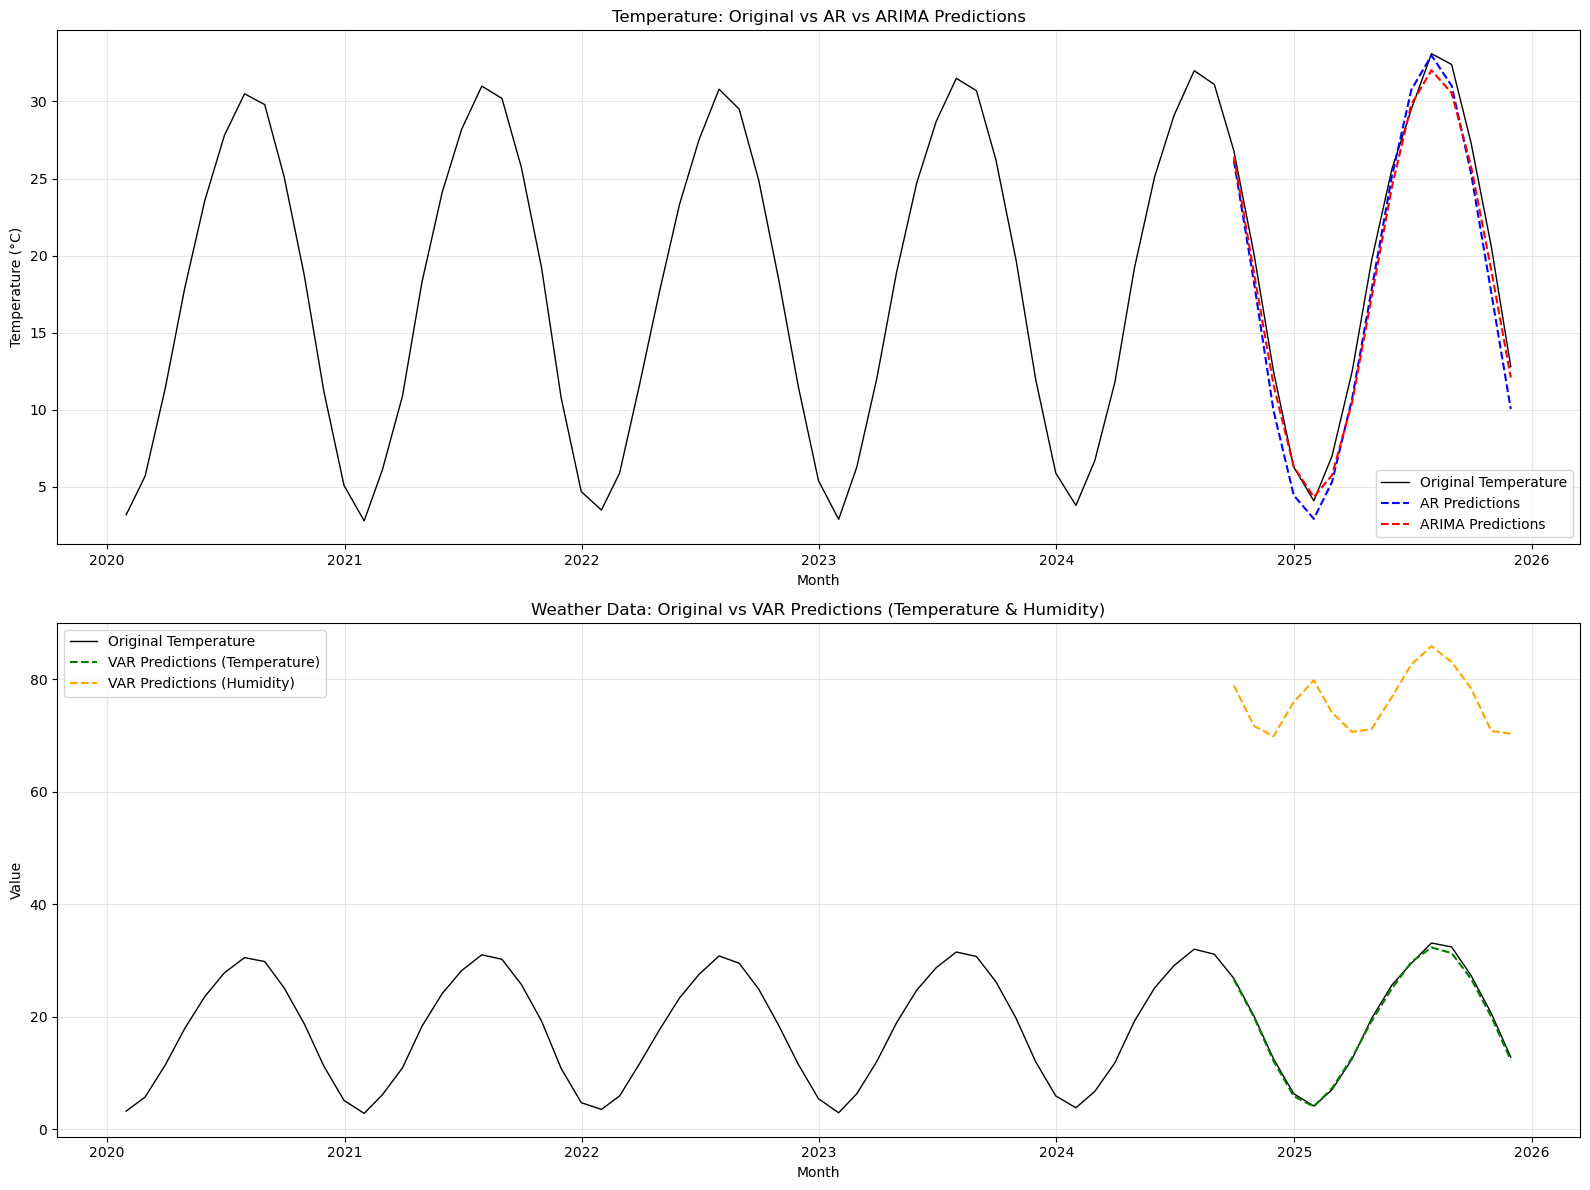

In [6]:
# Visualization Core: Plot the actual values, AR predictions, ARIMA predictions, and VAR predictions in a single figure for intuitive comparison.
plt.figure(figsize=(16, 12))

# Subplot 1: AR vs ARIMA (Univariate comparison for average temperature)
plt.subplot(2, 1, 1)
# Plot the original average temperature series (black solid line)
plt.plot(temp_series, label='Original Temperature', color='black', linewidth=1)
# Plot the AR model predictions (blue dashed line)
plt.plot(temp_test.index, ar_predictions, label='AR Predictions', color='blue', linestyle='--')
# Plot the ARIMA model predictions (red dashed line)
plt.plot(temp_test.index, arima_predictions, label='ARIMA Predictions', color='red', linestyle='--')
plt.title('Temperature: Original vs AR vs ARIMA Predictions')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()  # Display the legend for identifying different series
plt.grid(alpha=0.3)  # Add a light grid to enhance readability of the plot

# Subplot 2: VAR Model (Multivariate comparison for temperature & humidity)
plt.subplot(2, 1, 2)
# Plot the original average temperature series
plt.plot(df_core['Average_Temperature(Celsius)'], label='Original Temperature', color='black', linewidth=1)
# Plot the VAR model predictions for average temperature
plt.plot(var_predictions['Average_Temperature(Celsius)'], label='VAR Predictions (Temperature)', color='green', linestyle='--')
# Plot the VAR model predictions for humidity
plt.plot(var_predictions['Humidity(percentage)'], label='VAR Predictions (Humidity)', color='orange', linestyle='--')
plt.title('Weather Data: Original vs VAR Predictions (Temperature & Humidity)')
plt.xlabel('Month')
plt.ylabel('Value')
plt.legend()  # Display the legend for identifying different series
plt.grid(alpha=0.3)  # Add a light grid to enhance readability of the plot

# Adjust the layout of subplots to avoid overlapping elements (titles, labels, etc.)
plt.tight_layout()
# Display the figure (directly embedded below the code cell in Jupyter Notebook, no additional pop-up window)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller

In [10]:
df = pd.read_csv("Nanjing_Weather_Monthly_2020_2025_Cleaned.csv")
time_col = "Month"  
temp_col = "Average_Temperature(Celsius)" 

df[time_col] = pd.to_datetime(df[time_col])  
df.set_index(time_col, inplace=True)

try:
    core_cols = [temp_col, "Humidity(percentage)", "Wind_speed(m/s)", "Air_pressure(hPa)"]
    df = df[core_cols]
except KeyError:
    df = df[[temp_col]]    


In [11]:
# Extract temperature series (core prediction target)
data = df[temp_col].values

# Stationarity Test (ADF Test: determine if differencing is needed)
def adf_test(series):
    result = adfuller(series)
    print("\n【Stationarity Test Results】")
    print(f"ADF Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values (1%/5%/10% significance levels):", result[4])
    if result[1] < 0.05:
        print("Conclusion: The series is stationary, no differencing required")
        return True
    else:
        print("Conclusion: The series is non-stationary, first-order differencing required")
        return False

is_stationary = adf_test(data)
lags = 12  # Lag order (use data from the previous 6 months to predict the current month, consistent with your prior AR model)

# Construct lag features (AR model core input: X = lagged data, y = current period data)
if not is_stationary:
    # Non-stationary series: construct features after first-order differencing
    data_diff = np.diff(data)
    X = np.array([data_diff[i:i+lags] for i in range(len(data_diff)-lags)])
    y = data_diff[lags:]
else:
    # Stationary series: construct features directly
    X = np.array([data[i:i+lags] for i in range(len(data)-lags)])
    y = data[lags:]

# Split into training/test sets (8:2 ratio, strict time-series split to avoid data leakage)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\nData split completed:")
print(f"Training set samples: {len(X_train)} | Test set samples: {len(X_test)}")


【Stationarity Test Results】
ADF Test Statistic: 0.7577
p-value: 0.9909
Critical Values (1%/5%/10% significance levels): {'1%': -3.548493559596539, '5%': -2.912836594776334, '10%': -2.594129155766944}
Conclusion: The series is non-stationary, first-order differencing required

Data split completed:
Training set samples: 46 | Test set samples: 12


In [12]:
# Constructing Bayesian AR model
with pm.Model() as bayes_ar_model:
    # 1. Prior distribution setting 
    intercept = pm.Normal("intercept", mu=0, sigma=5)  # Intercept term
    ar_coeffs = pm.Normal("ar_coeffs", mu=0, sigma=1, shape=lags)  # AR coefficient
    sigma = pm.HalfNormal("sigma", sigma=5)  # Standard deviation of error term
    
    # 2. Linear prediction (core AR model formula)
    mu = intercept + pm.math.dot(X_train, ar_coeffs)
    
    # 3. Likelihood function (fit to training data)
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=y_train)
    
    # 4. MCMC sampling (parameter estimation)
    trace = pm.sample(
        4000, 
        tune=3000, 
        cores=4, 
        random_seed=42, 
        return_inferencedata=True,
        progressbar=True
    )

summary = pm.summary(trace).round(2)
print(summary)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, ar_coeffs, sigma]


Output()

Sampling 4 chains for 3_000 tune and 4_000 draw iterations (12_000 + 16_000 draws total) took 100 seconds.


               mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept      0.14  0.09   -0.04     0.30        0.0      0.0    7539.0   
ar_coeffs[0]   0.26  0.17   -0.05     0.59        0.0      0.0    3875.0   
ar_coeffs[1]  -0.12  0.17   -0.44     0.21        0.0      0.0    3437.0   
ar_coeffs[2]  -0.50  0.16   -0.82    -0.21        0.0      0.0    3773.0   
ar_coeffs[3]  -0.29  0.17   -0.61     0.02        0.0      0.0    3475.0   
ar_coeffs[4]  -0.46  0.17   -0.79    -0.15        0.0      0.0    3490.0   
ar_coeffs[5]  -0.46  0.16   -0.76    -0.16        0.0      0.0    3633.0   
ar_coeffs[6]  -0.30  0.16   -0.59     0.01        0.0      0.0    3617.0   
ar_coeffs[7]  -0.37  0.16   -0.68    -0.06        0.0      0.0    3396.0   
ar_coeffs[8]  -0.46  0.16   -0.76    -0.15        0.0      0.0    3337.0   
ar_coeffs[9]  -0.43  0.16   -0.72    -0.13        0.0      0.0    3656.0   
ar_coeffs[10] -0.33  0.17   -0.64    -0.01        0.0      0.0    3491.0   
ar_coeffs[11

In [13]:
def bayesian_predict(trace, X_data, lags=6):
    """
    Bayesian prediction for temperature based on posterior samples of AR model
    
    Parameters:
        trace (arviz.InferenceData): Trained Bayesian AR model posterior samples
        X_data (np.ndarray): Input lag features (shape: [n_samples, lags])
        lags (int): Number of lagged time steps (default: 6 months)
    
    Returns:
        pred_mean (np.ndarray): Mean of predicted values (shape: [n_samples])
        pred_lower (np.ndarray): 2.5th percentile (lower bound of 95% CI)
        pred_upper (np.ndarray): 97.5th percentile (upper bound of 95% CI)
    """
       # Flatten intercept samples to 1D array (shape: [total_posterior_samples])
    intercept_samples = trace.posterior["intercept"].values.flatten()
    
    # Reshape AR coefficients to [total_posterior_samples, lags] for matrix multiplication
    # Original shape: [n_chains, n_draws, lags] → Reshaped to [n_chains*n_draws, lags]
    ar_coeffs_samples = trace.posterior["ar_coeffs"].values.reshape(-1, lags)
    
    # Calculate predictions for each posterior sample (Monte Carlo simulation)
    preds = []
    for i in range(len(intercept_samples)):
        # Bayesian AR model formula: y = intercept + Σ(AR_coeff * lagged_X)
        pred = intercept_samples[i] + np.dot(X_data, ar_coeffs_samples[i])
        preds.append(pred)
    preds = np.array(preds)  # Shape: [total_posterior_samples, n_samples]
    
    # Compute statistical summary of posterior predictions
    pred_mean = preds.mean(axis=0)                  # Mean prediction (point estimate)
    pred_lower = np.percentile(preds, 2.5, axis=0)  # 2.5th percentile (95% CI lower bound)
    pred_upper = np.percentile(preds, 97.5, axis=0) # 97.5th percentile (95% CI upper bound)
    
    return pred_mean, pred_lower, pred_upper


def inverse_difference(pred_diff, last_true_value):
    """
    Invert first-order differencing to recover original temperature scale
    Critical for non-stationary time series (convert diff predictions → actual temperature)
    
    Parameters:
        pred_diff (np.ndarray): Predicted differenced values (ΔT)
        last_true_value (float): Last observed temperature before prediction period
    
    Returns:
        original_values (np.ndarray): Predicted temperatures in original scale (°C)
    """
    original_values = []
    current_value = last_true_value  # Initialize with last real temperature
    
    # Cumulative sum to reverse differencing: T_t = T_{t-1} + ΔT_t
    for diff in pred_diff:
        current_value += diff
        original_values.append(current_value)
    
    return np.array(original_values)


def forecast_future_temp(trace, last_lags, is_stationary, last_true_temp, lags=6, n_steps=6):
    """
    Rolling forecast for future temperature (multi-step ahead prediction)
    Uses predicted values from previous step as lag features for next step
    
    Parameters:
        trace (arviz.InferenceData): Trained Bayesian AR model posterior samples
        last_lags (np.ndarray): Last lags of observed data (shape: [lags])
        is_stationary (bool): Whether time series is stationary (no differencing needed)
        last_true_temp (float): Last observed temperature (for differencing inversion)
        lags (int): Number of lagged time steps (default: 6)
        n_steps (int): Number of future months to predict (default: 6)
    
    Returns:
        forecast_mean (np.ndarray): Mean of future temperature predictions
        forecast_lower (np.ndarray): 2.5th percentile (95% CI lower bound)
        forecast_upper (np.ndarray): 97.5th percentile (95% CI upper bound)
    """
    # Initialize storage for forecast results
    forecast_mean = []
    forecast_lower = []
    forecast_upper = []
    
    # Initial lag values (last 6 months of observed data)
    current_lags = last_lags.copy()  # Avoid modifying original array
    
    # Iterative rolling prediction for n future steps
    for _ in range(n_steps):
        # Predict current step (reshape to 2D array for bayesian_predict input)
        pred_m, pred_l, pred_u = bayesian_predict(trace, current_lags.reshape(1, -1), lags)
        
        # Store prediction results (extract scalar value from 1-element array)
        forecast_mean.append(pred_m[0])
        forecast_lower.append(pred_l[0])
        forecast_upper.append(pred_u[0])
        
        # Update lag features for next step (rolling window)
        # Shift left by 1 → discard oldest lag, add new prediction as newest lag
        current_lags = np.roll(current_lags, -1)
        current_lags[-1] = pred_m[0]  # Use mean prediction for next step (point estimate)
    
    # Invert differencing if series is non-stationary (convert ΔT → T)
    if not is_stationary:
        forecast_mean = inverse_difference(forecast_mean, last_true_temp)
        forecast_lower = inverse_difference(forecast_lower, last_true_temp)
        forecast_upper = inverse_difference(forecast_upper, last_true_temp)
    
    # Convert to numpy arrays for consistency
    return np.array(forecast_mean), np.array(forecast_lower), np.array(forecast_upper)

In [14]:
# Generate predictions for test set (X_test and y_test now have matching lengths)
y_pred_mean, y_pred_lower, y_pred_upper = bayesian_predict(trace, X_test, lags)

# Invert differencing (ensure strict length matching between predictions and true values)
if not is_stationary:
  
    test_start_idx = len(data) - len(data_diff) + train_size + lags
    # Last observed temperature before test set (used to invert differencing)
    last_true_train = data[test_start_idx - 1]
    # Strictly slice true test set values to match prediction length (avoid dimension mismatch)
    y_test_original = data[test_start_idx : test_start_idx + len(y_test)]
    
    # Convert differenced predictions back to original temperature scale (°C)
    y_pred_original = inverse_difference(y_pred_mean, last_true_train)
    y_pred_lower_original = inverse_difference(y_pred_lower, last_true_train)
    y_pred_upper_original = inverse_difference(y_pred_upper, last_true_train)
else:
    # For stationary series: use raw values directly (lengths already matched)
    y_test_original = y_test
    y_pred_original = y_pred_mean
    y_pred_lower_original = y_pred_lower
    y_pred_upper_original = y_pred_upper

# Calculate RMSE for test set 
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
print(f"\n【Temperature Test Set RMSE】: {rmse:.2f} °C")


【Temperature Test Set RMSE】: 0.65 °C


In [15]:
# Extract the last 6 lagged values as initial inputs for forecasting
if not is_stationary:
    # For non-stationary time series: use differenced values (ΔT) for initial lags
    last_lags_temp = np.diff(data)[-lags:]
    # Store the final observed temperature (for reversing differencing later)
    last_true_temp = data[-1]
else:
    # For stationary time series: use raw temperature values for initial lags
    last_lags_temp = data[-lags:]
    last_true_temp = data[-1]

# Generate 6-month ahead temperature forecast (rolling multi-step prediction)
future_mean, future_lower, future_upper = forecast_future_temp(
    trace, last_lags_temp, is_stationary, last_true_temp, lags, n_steps=6
)

# Print future forecast results (95% Credible Interval for Bayesian predictions)
print(f"\n【6-Month Temperature Forecast (95% Credible Interval)】")
for i in range(6):
    print(f"Month {i+1}: {future_mean[i]:.2f} °C (95% CI: {future_lower[i]:.2f} to {future_upper[i]:.2f} °C)")


【6-Month Temperature Forecast (95% Credible Interval)】
Month 1: 6.66 °C (95% CI: 6.03 to 7.30 °C)
Month 2: 4.97 °C (95% CI: 3.71 to 6.25 °C)
Month 3: 7.32 °C (95% CI: 5.46 to 9.20 °C)
Month 4: 12.72 °C (95% CI: 10.28 to 15.19 °C)
Month 5: 19.96 °C (95% CI: 16.92 to 23.00 °C)
Month 6: 25.76 °C (95% CI: 22.16 to 29.39 °C)


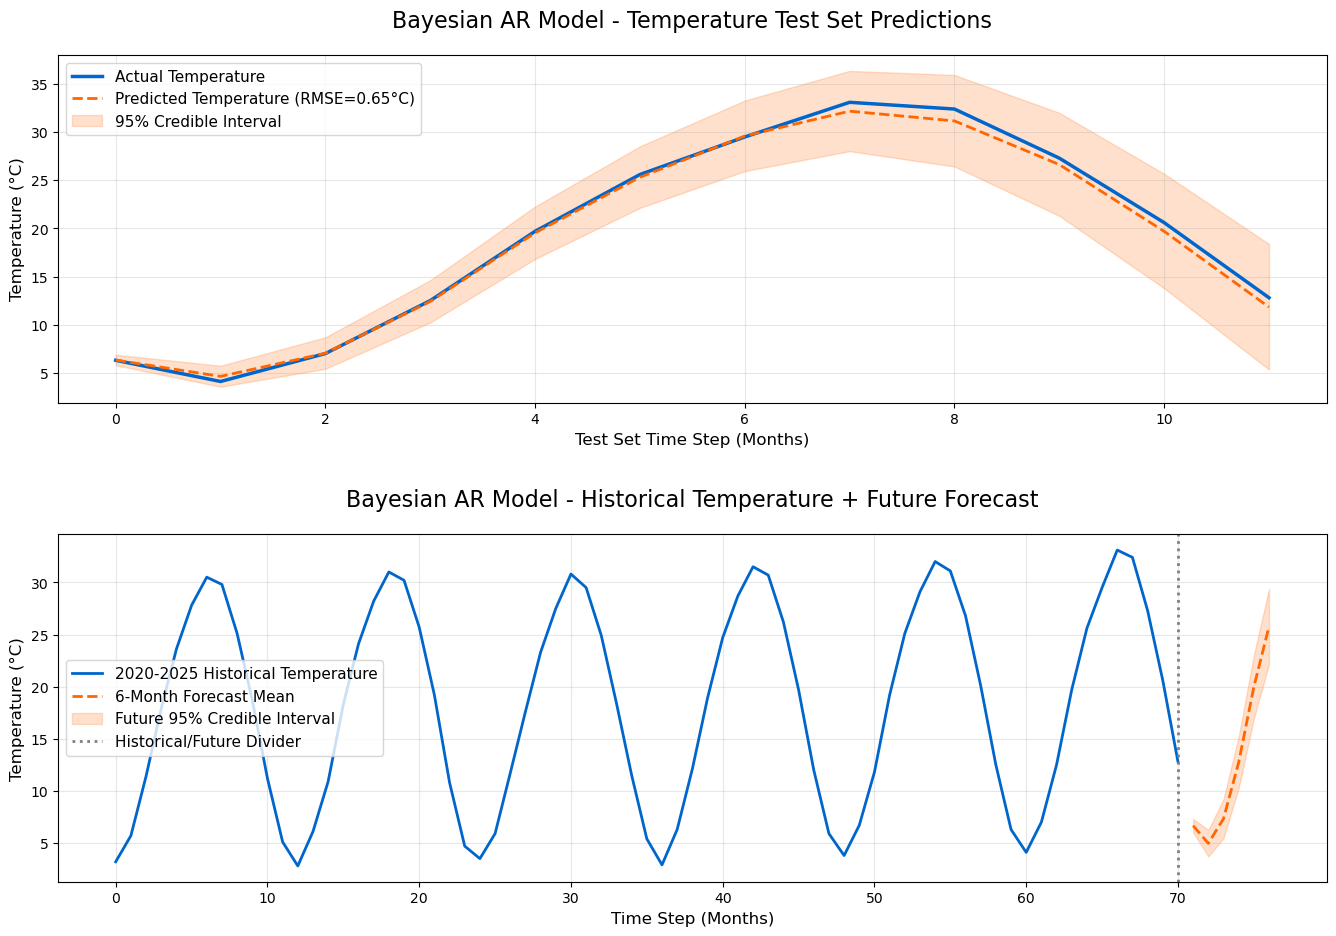

In [16]:
# Temperature Prediction Visualization (temperature only; logic applies to other variables)
# Configure plot settings for English display 
plt.rcParams["axes.unicode_minus"] = False  # Preserve minus sign rendering
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Subplot 1: Test Set - Actual vs. Predicted Values
ax1.plot(range(len(y_test_original)), y_test_original, color="#0066CC", linewidth=2.5, label="Actual Temperature")
ax1.plot(range(len(y_pred_original)), y_pred_original, color="#FF6600", linewidth=2, linestyle="--", label=f"Predicted Temperature (RMSE={rmse:.2f}°C)")
ax1.fill_between(range(len(y_pred_original)), y_pred_lower_original, y_pred_upper_original, color="#FF6600", alpha=0.2, label="95% Credible Interval")
ax1.set_title("Bayesian AR Model - Temperature Test Set Predictions", fontsize=16, pad=20)
ax1.set_xlabel("Test Set Time Step (Months)", fontsize=12)
ax1.set_ylabel("Temperature (°C)", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Subplot 2: Historical Temperature + 6-Month Future Forecast
x_hist = range(len(data))  # X-axis for historical data
x_future = range(len(data), len(data)+6)  # X-axis for future forecast
ax2.plot(x_hist, data, color="#0066CC", linewidth=2, label="2020-2025 Historical Temperature")
ax2.plot(x_future, future_mean, color="#FF6600", linewidth=2, linestyle="--", label="6-Month Forecast Mean")
ax2.fill_between(x_future, future_lower, future_upper, color="#FF6600", alpha=0.2, label="Future 95% Credible Interval")
ax2.axvline(x=len(data)-1, color="gray", linestyle=":", linewidth=2, label="Historical/Future Divider")
ax2.set_title("Bayesian AR Model - Historical Temperature + Future Forecast", fontsize=16, pad=20)
ax2.set_xlabel("Time Step (Months)", fontsize=12)
ax2.set_ylabel("Temperature (°C)", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Adjust subplot spacing to prevent overlap
plt.tight_layout(pad=3.0)
plt.show()

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.vector_ar.var_model import VAR

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"

In [2]:
df = pd.read_csv("Nanjing_Weather_Monthly_2020_2025_Cleaned.csv")

time_col = "Month"
vars_cols = [
    "Average_Temperature(Celsius)",
    "Humidity(percentage)",
    "Air_pressure(hPa)",
    "Wind_speed(m/s)"
]

#Seasonal characteristics
df['month'] = np.arange(1, len(df)+1) % 12
df['month'] = df['month'].replace(0, 12)
df['sin_t'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_t'] = np.cos(2 * np.pi * df['month'] / 12)
vars_cols += ['sin_t', 'cos_t']

#Date processing
df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
df = df.dropna(subset=vars_cols)
df = df.set_index(time_col)

data_multi = df[vars_cols].values
n_var = data_multi.shape[1]

#Standardization
scaler = StandardScaler()
data_multi_standardized = scaler.fit_transform(data_multi)


In [3]:
def adf_test(series):
    return adfuller(series)[1] < 0.05

stationary_list = [adf_test(data_multi_standardized[:, i]) for i in range(n_var)]
is_stationary = all(stationary_list)
print(f"Is the data stable or not：{is_stationary}")

#Choose the optimal lag
def select_best_lag(data, max_lag=9):
    try:
        model = VAR(data)
        best_aic = np.inf
        best_lag = 2
        for l in range(1, max_lag+1):
            res = model.fit(l)
            if res.aic < best_aic:
                best_aic = res.aic
                best_lag = l
        return best_lag
    except:
        return 2

lags = select_best_lag(data_multi if is_stationary else np.diff(data_multi, axis=0))
print("optimal lag =", lags)

Is the data stable or not：False
optimal lag = 6


In [4]:
if not is_stationary:
    data_diff = np.diff(data_multi_standardized, axis=0)
    
    last_original_value = data_multi_standardized[-1, :]
else:
    data_diff = data_multi_standardized
    last_original_value = None

X, y = [], []
for i in range(len(data_diff) - lags):
    X.append(data_diff[i:i+lags].flatten())
    y.append(data_diff[i+lags])

X = np.array(X)
y = np.array(y)

#Training Test Set
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

if not is_stationary:
    test_original_values = data_multi_standardized[train_size+lags : train_size+lags+len(y_test), :]
else:
    test_original_values = None

In [5]:
with pm.Model() as bvar_model:
    intercept = pm.Normal('intercept', mu=0, sigma=0.3, shape=n_var)
    beta = pm.Normal('beta', mu=0, sigma=0.2, shape=(lags*n_var, n_var))
    sigma = pm.HalfNormal('sigma', sigma=0.3, shape=n_var)

    mu = pm.math.dot(X_train, beta) + intercept
    for i in range(n_var):
        pm.Normal(f'like_{i}', mu=mu[:, i], sigma=sigma[i], observed=y_train[:, i])

    trace = pm.sample(draws=2000, tune=1000, chains=2, target_accept=0.95, random_seed=42)

print("Rhat < 1.01：")
print(az.rhat(trace))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 783 seconds.
There were 1280 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Rhat < 1.01：
<xarray.Dataset> Size: 2kB
Dimensions:          (intercept_dim_0: 6, beta_dim_0: 36, beta_dim_1: 6,
                      sigma_dim_0: 6)
Coordinates:
  * intercept_dim_0  (intercept_dim_0) int32 24B 0 1 2 3 4 5
  * beta_dim_0       (beta_dim_0) int32 144B 0 1 2 3 4 5 6 ... 30 31 32 33 34 35
  * beta_dim_1       (beta_dim_1) int32 24B 0 1 2 3 4 5
  * sigma_dim_0      (sigma_dim_0) int32 24B 0 1 2 3 4 5
Data variables:
    intercept        (intercept_dim_0) float64 48B 1.968 1.847 ... 1.901 1.987
    beta             (beta_dim_0, beta_dim_1) float64 2kB 1.938 2.09 ... 2.014
    sigma            (sigma_dim_0) float64 48B 2.731 2.191 1.866 ... 2.998 2.257
Attributes:
    created_at:                 2026-04-25T19:37:48.292803+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.20.1
    sampling_time:              782.6893138885498
    tuning_steps:               1000


In [24]:
def predict_var_restore(trace, X_data, last_known_value, is_stationary):
    intercept = trace.posterior['intercept'].values.reshape(-1, n_var)
    beta = trace.posterior['beta'].values.reshape(-1, lags*n_var, n_var)
    
    # Predict the difference (change amount) first
    diff_preds = np.array([X_data @ b + a for a, b in zip(intercept, beta)])
    
    if not is_stationary:
        original_preds = np.zeros_like(diff_preds)
        n_samples = diff_preds.shape[0]
        n_steps = diff_preds.shape[1]
        
        for sample in range(n_samples):
           
            current_val = last_known_value.copy()
            for step in range(n_steps):
                # Recursive: current value=predicted value from the previous step+predicted difference
                current_val = current_val + diff_preds[sample, step, :]
                original_preds[sample, step, :] = current_val
        return original_preds
    else:
        return diff_preds

# Test set prediction (restored to the original standardized scale)
last_known = data_multi_standardized[train_size + lags , :]
all_traces = predict_var_restore(trace, X_test, last_known, is_stationary)

mu = all_traces.mean(axis=0)
low = np.percentile(all_traces, 2.5, axis=0)
upp = np.percentile(all_traces, 97.5, axis=0)

temp_true = data_multi_standardized[train_size+lags+1 : train_size+lags+1+len(y_test), 0]
temp_pred = all_traces.mean(axis=0)[:, 0]

rmse = np.sqrt(mean_squared_error(temp_true, temp_pred))
print(f"\n test set RMSE = {rmse:.3f} °C")


 test set RMSE = 0.230 °C


In [17]:
def forecast_future_restore(trace, last_lag, last_original_value, steps, is_stationary):
 
    intercept = trace.posterior['intercept'].values.reshape(-1, n_var)
    beta = trace.posterior['beta'].values.reshape(-1, lags*n_var, n_var)
    n_samples = len(intercept)
    

    fut_original_preds = np.zeros((n_samples, steps, n_var))
    
    for s in range(n_samples):
        cl = last_lag.copy()

        prev_original = last_original_value.copy()
        
        for step in range(steps):
        
            diff_pred = cl.reshape(1, -1) @ beta[s] + intercept[s]
       
            original_pred = prev_original + diff_pred[0]
            fut_original_preds[s, step, :] = original_pred
            
            cl = np.roll(cl, -n_var)
            cl[-n_var:] = diff_pred[0]
            prev_original = original_pred
    
    return fut_original_preds

# Forecast for the next 12 months
fut_traces_full = forecast_future_restore(trace, X_test[-1], last_original_value, 12, is_stationary)
fut_traces = fut_traces_full[:, :, 0]  
fut_mean = fut_traces.mean(axis=0)
fut_low = np.percentile(fut_traces, 2.5, axis=0)
fut_upp = np.percentile(fut_traces, 97.5, axis=0)

([<matplotlib.axis.XTick at 0x1fa5ba63b60>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

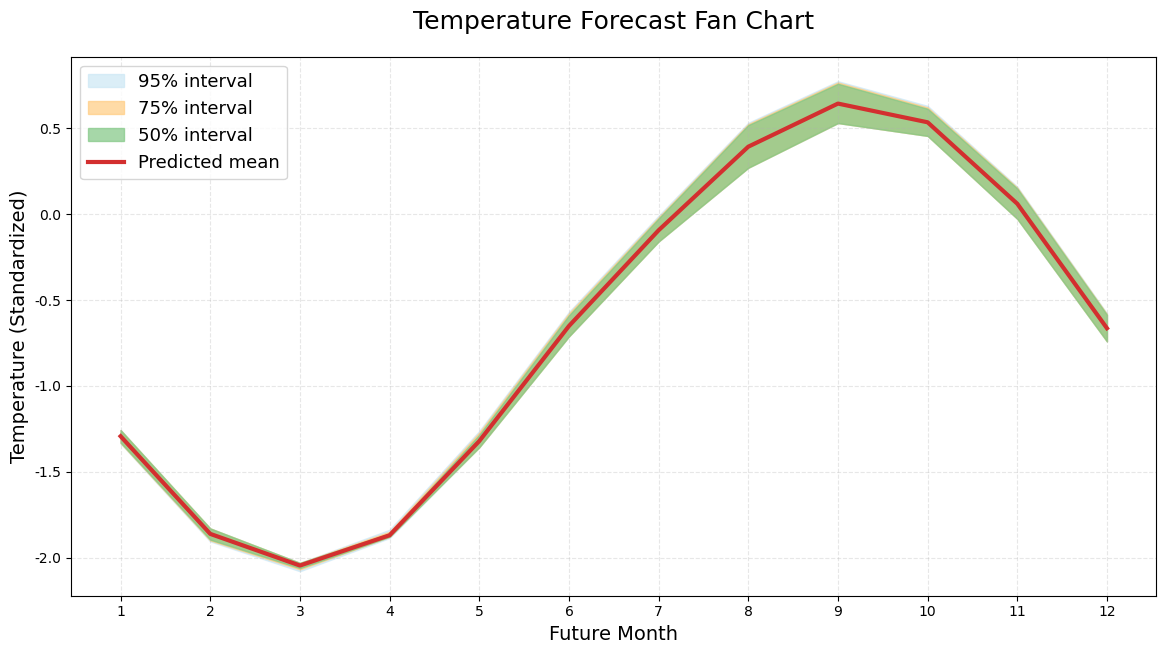

In [25]:
# ----FAN CHART----

plt.figure(figsize=(14, 7))

# 1. Define confidence interval hierarchy
ci_levels = [95, 75, 50]
colors = ['#cce7f5', '#ffcc80', '#81c784']
labels = ['95% interval', '75% interval', '50% interval']

# 2. Calculate the confidence interval for each step size (automatically accumulate errors to form a sector)
x_future = np.arange(1, 13)  # 未来12个月

for ci, color, label in zip(ci_levels, colors, labels):
    lower = np.percentile(fut_traces, (100 - ci)/2, axis=0)
    upper = np.percentile(fut_traces, 100 - (100 - ci)/2, axis=0)
    plt.fill_between(x_future, lower, upper, color=color, alpha=0.7, label=label)

# 3.Plot the predicted mean line
plt.plot(x_future, fut_mean, color='#d32f2f', linewidth=3, label='Predicted mean')

plt.title("Temperature Forecast Fan Chart", fontsize=18, pad=20)
plt.xlabel("Future Month", fontsize=14)
plt.ylabel("Temperature (Standardized)", fontsize=14)
plt.legend(fontsize=13, loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.xticks(x_future)

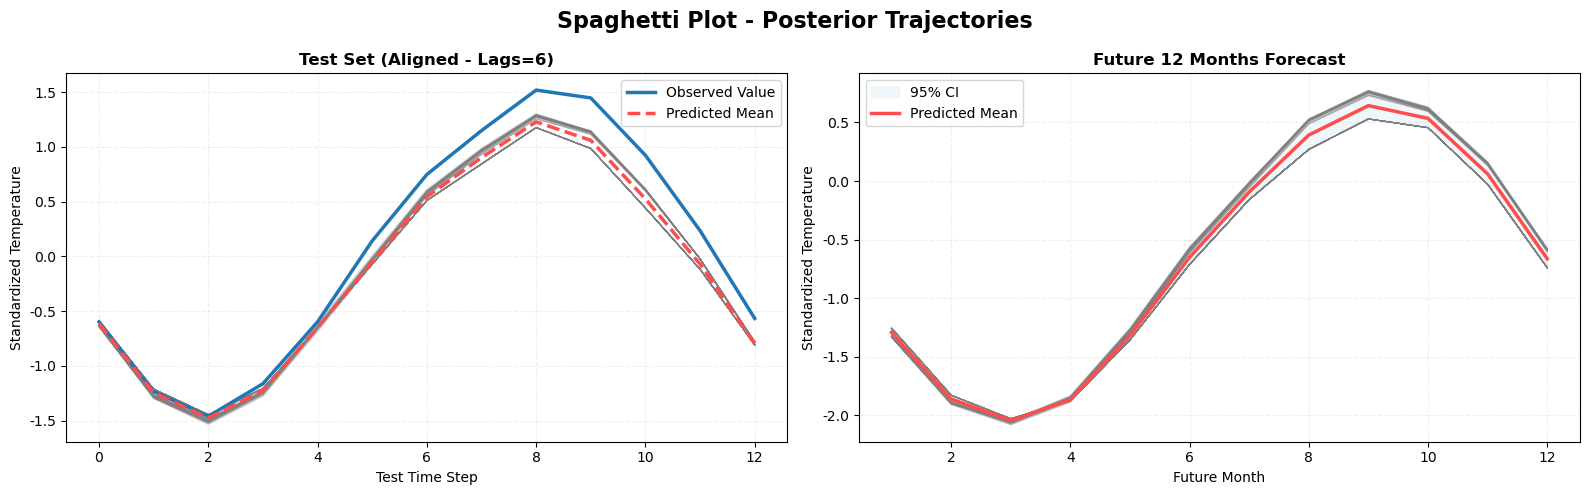

In [26]:
#----Spaghetti Plot----

plt.rcParams["axes.unicode_minus"] = False
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Spaghetti Plot - Posterior Trajectories", fontsize=16, weight='bold')

# Left image: Test set
x_test = np.arange(len(temp_true))
for i in np.random.choice(all_traces.shape[0], 150, replace=False):
    ax1.plot(x_test, all_traces[i, :, 0], color='gray', alpha=0.15, linewidth=0.7)

# Real value+predicted mean
ax1.plot(x_test, temp_true, '#1f77b4', linewidth=2.5, label='Observed Value')
ax1.plot(x_test, temp_pred, '#ff4c4c', linestyle='--', linewidth=2.5, label='Predicted Mean')

ax1.set_title(f"Test Set (Aligned - Lags={lags})", fontsize=12, weight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.2, linestyle='--')
ax1.set_xlabel("Test Time Step")
ax1.set_ylabel("Standardized Temperature")

# Right picture: Next 12 months
x_fut = np.arange(1, 13)
for i in np.random.choice(fut_traces.shape[0], 150, replace=False):
    ax2.plot(x_fut, fut_traces[i], color='gray', alpha=0.15, linewidth=0.7)

ax2.fill_between(x_fut, fut_low, fut_upp, color='#cce7f5', alpha=0.3, label='95% CI')
ax2.plot(x_fut, fut_mean, '#ff4c4c', linewidth=2.5, label='Predicted Mean')

ax2.set_title("Future 12 Months Forecast", fontsize=12, weight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.2, linestyle='--')
ax2.set_xlabel("Future Month")
ax2.set_ylabel("Standardized Temperature")

plt.tight_layout()
plt.show()


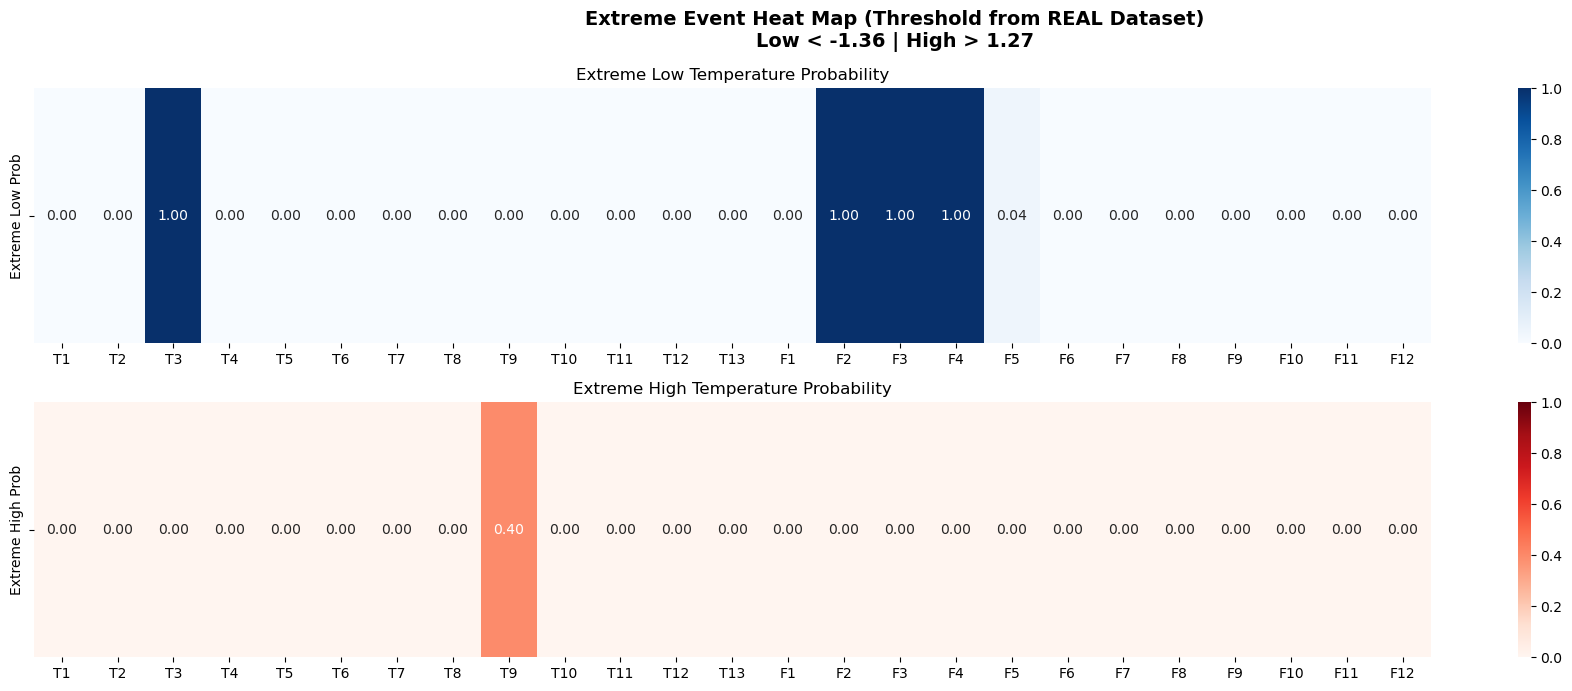

 Real data 10% percentile (extreme low temperature threshold)= -1.36
90% percentile of real data (extreme high temperature threshold)）= 1.27
 Probability of the highest low temperature in the test set = 1.00
 Probability of the highest future high temperature = 0.00


In [27]:
true_temp_full = data_multi_standardized[:, 0]
LOW_TEMP_THRESH = np.percentile(true_temp_full, 10)
HIGH_TEMP_THRESH = np.percentile(true_temp_full, 90)

# Calculate the probability of the model's prediction exceeding the true threshold
test_low_prob = (all_traces[:, :, 0] < LOW_TEMP_THRESH).mean(axis=0)
test_high_prob = (all_traces[:, :, 0] > HIGH_TEMP_THRESH).mean(axis=0)

fut_low_prob = (fut_traces < LOW_TEMP_THRESH).mean(axis=0)
fut_high_prob = (fut_traces > HIGH_TEMP_THRESH).mean(axis=0)

all_low_prob = np.concatenate([test_low_prob, fut_low_prob])
all_high_prob = np.concatenate([test_high_prob, fut_high_prob])

time_labels = [f"T{i+1}" for i in range(len(test_low_prob))] + [f"F{i+1}" for i in range(12)]

# -----Heat Map-----
plt.rcParams["axes.unicode_minus"] = False
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 7), tight_layout=True)
fig.suptitle(f"Extreme Event Heat Map (Threshold from REAL Dataset)\nLow < {LOW_TEMP_THRESH:.2f} | High > {HIGH_TEMP_THRESH:.2f}", 
             fontsize=14, weight='bold')

# Low-temperature heat map
sns.heatmap(all_low_prob.reshape(1, -1), cmap="Blues", annot=True, fmt=".2f",
            xticklabels=time_labels, ax=ax1, yticklabels=["Extreme Low Prob"],
            vmin=0, vmax=1) 
ax1.set_title("Extreme Low Temperature Probability")

# High-temperature heat map
sns.heatmap(all_high_prob.reshape(1, -1), cmap="Reds", annot=True, fmt=".2f",
            xticklabels=time_labels, ax=ax2, yticklabels=["Extreme High Prob"],
            vmin=0, vmax=1)
ax2.set_title("Extreme High Temperature Probability")

plt.show()

print(f" Real data 10% percentile (extreme low temperature threshold)= {LOW_TEMP_THRESH:.2f}")
print(f"90% percentile of real data (extreme high temperature threshold)）= {HIGH_TEMP_THRESH:.2f}")
print(f" Probability of the highest low temperature in the test set = {test_low_prob.max():.2f}")
print(f" Probability of the highest future high temperature = {fut_high_prob.max():.2f}")